## Preprocessing (For Each Source)
1. Filter rows by source

2. Clean numeric fields (e.g., convert usage, usage_med, usage_med_sqft to float)

3. Drop irrelevant or mostly missing columns

4. Choose predictors (e.g., sqft, usetype, year, med_income, etc.)

5. Define usage as your outcome

6. Run a regression or ML model

### The Source Files and the Corresponding Colummns
 1. **'usage_bld_kwh.csv'** <br>
Columns: ([geo_id', 'sqft', 'usage', 'usage_med', 'usage_med_sqft', 'usetype', 'year', 'name', 'solar_potential', 'pop', 'usage_percap', 'source']) <br>
---**Double check the column solar_potential: solar_potential column is all blank, no reason to keep it!**<br>
---**Double check the column year: year column is all 2016, no variation so no reason to keep it!**<br>
**Dependent Variables:** usage_med<br>
**Independent Variables:** xxx<br>

 3. **'usage_vintage_kwh.csv'** <br>
Columns: (['geo_id', 'sqft', 'usage', 'usage_med', 'usage_med_sqft', 'usetype', 'vintage_id', 'year', 'name', 'source'])<br>

 4. **'usage_income_kwh.csv'** <br>
Columns: (['geo_id', 'year', 'income_quintile', 'income_range', 'usage', 'pop', 'usetype', 'usage_percap', 'name', 'source'])<br>

 5. **'usage_sqft_kwh.csv'** <br>
Columns: (['geo_id', 'sqft', 'sqft_id', 'usage', 'usage_med', 'usage_med_sqft', 'usetype', 'year', 'name', 'source'])<br>
predicting: usage_med_sqft

 6. **'geos.csv'** <br>
Columns: (['geo_id', 'name', 'pop', 'pop_sqmi', 'med_income', 'pct_own', 'pct_rent', 'year', 'enviroscreen_tracts', 'sqmi', 'solar_pot', 'net_solar_pot', 'count', 'source'])<br>


In [278]:
# Defining the data types for when reading the csv, to prevent getting the warning error message.
dtype_dict = {
    'geo_id': 'string', 'sqft': 'float64', 'usage': 'float64',
    'usage_med': 'float64', 'usage_med_sqft': 'float64', 'usetype': 'string',
    'year': int, 'name': 'string', 'solar_potential': 'float64',
    'pop': 'float64', 'usage_percap': 'float64', 'source': 'string',
    'vintage_id': 'float64', 'income_quintile': 'float64', 'income_range': 'string',
    'sqft_id': 'float64', 'pop_sqmi': 'float64', 'med_income': 'float64',
    'pct_own': 'float64', 'pct_rent': 'float64', 'enviroscreen_tracts': 'float64',
    'sqmi': 'float64', 'solar_pot': 'float64', 'net_solar_pot': 'float64',
    'count': 'float64', 'query': 'string', 'postal_code': 'float64',
    'city': 'string', 'county': 'string', 'neighborhood': 'string',
    'lat': 'float64', 'lng': 'float64'
}

## Exploring and Processing the data

### Workflow
- Download ucla_final.csv
- Filter rows with non-missing usage_med / or use the median values of usage_med when missing usage_med
- Choose good features for every source file (e.g., sqft, city, year, usetype, etc.)
- Impute missing features (median for numbers, "Unknown" for text)
- Train model (CatBoostRegressor)
- Evaluate (Check R square and analyze the results)
- Predict missing values if needed

## Preprocessing

In [263]:
# Preprocessing the data (This was identical in every code block)
# Load and preprocess everything in one block
import pandas as pd

df = pd.read_csv("ucla_final.csv", low_memory=False)

# 1. Replace "masked" with proper NA
df = df.replace("masked", pd.NA)

# 2. Convert all relevant numeric columns
df['usage_med'] = pd.to_numeric(df['usage_med'], errors='coerce')
df['usage_percap'] = pd.to_numeric(df['usage_percap'], errors='coerce')
df['sqft'] = pd.to_numeric(df['sqft'], errors='coerce')

df['usage'] = pd.to_numeric(df['usage'], errors='coerce')
df['usage_med_sqft'] = pd.to_numeric(df['usage_med_sqft'], errors='coerce')

# 3. Impute sqft with median
df['sqft'] = df['sqft'].fillna(df['sqft'].median())

# 4. Fill all common categorical fields
for col in ['city', 'county', 'postal_code', 'neighborhood', 'income_range', 'sqft_id', 'vintage_id', 'usetype']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# 5. Ensure certain fields are strings
for col in ['postal_code', 'income_range', 'sqft_id', 'vintage_id']:
    if col in df.columns:
        df[col] = df[col].astype(str)

#display(df)

In [3]:
# No more cleaning needed here
df_bld = df[(df['source'] == 'usage_bld_kwh') & df['usage_med'].notna()].copy()
df_vintage = df[(df['source'] == 'usage_vintage_kwh') & df['usage_med'].notna()].copy()
df_income = df[(df['source'] == 'usage_income_kwh') & df['usage_percap'].notna()].copy()
df_sqft = df[(df['source'] == 'usage_sqft_kwh') & df['usage_med'].notna()].copy()


---
# usage_bld_kwh
Predicting usage_med

In [5]:
# NEW WAY Only use these columns (same as before)

df_bld = df[(df['source'] == 'usage_bld_kwh') & df['usage_med'].notna()].copy()

df_bld = df_bld[['geo_id', 'sqft', 'usage', 'usage_med', 'usage_med_sqft', 'usetype', 'year', 'name', 'pop',
                 'usage_percap', 'source', 'query', 'postal_code', 'city', 'county', 'neighborhood', 'lat', 'lng']]

# Create copies for optional exploration (like you did before)
df_sample_testing = df_bld.copy()
df_sample_copy = df_bld.copy()

# Display full df_bld
display(df_bld)

# Display filtered version where usage_med is present (already filtered above, but to match original flow)
#display(df_bld)

# Count non-missing values
non_missing_counts = df_bld.notna().sum()
print("Non-missing values per column:\n")
print(non_missing_counts)


,geo_id,sqft,usage,usage_med,usage_med_sqft,usetype,year,name,pop,usage_percap,source,query,postal_code,city,county,neighborhood,lat,lng
1,cities_1,4802115.0,65825608.0,121901.00,9.7676,commercial,2016,agoura hills,NaN,NaN,usage_bld_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,34.153340,-118.761676
2,cities_1,8906397.0,43707916.6,9136.00,3.9839,condo,2016,agoura hills,NaN,NaN,usage_bld_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,34.153340,-118.761676
5,cities_1,742420.0,2010646.5,70823.00,3.2102,multi_family,2016,agoura hills,NaN,NaN,usage_bld_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,34.153340,-118.761676
9,cities_1,14557697.0,70081933.1,9369.00,4.0788,res_total,2016,agoura hills,20236.0,3463.2305,usage_bld_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,34.153340,-118.761676
10,cities_1,4862180.0,22023992.5,9761.50,4.2576,single_family,2016,agoura hills,NaN,NaN,usage_bld_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,34.153340,-118.761676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5757,neighborhoods_98,30531500.0,142698991.6,5643.00,3.7424,res_total,2016,carson,92200.0,1547.7114,usage_bld_kwh,"carson, CA",Unknown,Carson,Los Angeles County,Unknown,33.831674,-118.281693
5758,neighborhoods_98,26128668.0,102852894.6,5541.00,3.7457,single_family,2016,carson,NaN,NaN,usage_bld_kwh,"carson, CA",Unknown,Carson,Los Angeles County,Unknown,33.831674,-118.281693
5765,neighborhoods_99,1876565.0,5754626.4,11137.70,2.9145,multi_family,2016,carthay,NaN,NaN,usage_bld_kwh,"carthay, CA",90035.0,Los Angeles,Los Angeles County,Carthay Square,34.055838,-118.368030
5769,neighborhoods_99,3432343.0,12882566.3,9324.95,3.4193,res_total,2016,carthay,5201.0,2476.9403,usage_bld_kwh,"carthay, CA",90035.0,Los Angeles,Los Angeles County,Carthay Square,34.055838,-118.368030


Non-missing values per column:

geo_id            2366
sqft              2366
usage             2366
usage_med         2366
usage_med_sqft    2249
usetype           2366
year              2366
name              2366
pop                429
usage_percap       429
source            2366
query             2366
postal_code       2366
city              2366
county            2366
neighborhood      2366
lat               2356
lng               2356
dtype: int64


In [7]:
# CatBoost Model
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

selected_features = ['sqft', 'usetype', 'year', 'city', 'county', 'postal_code', 'neighborhood']
target = 'usage_med'

# Prepare X and y
X = df_bld[selected_features]
y = pd.to_numeric(df_bld[target], errors='coerce')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CatBoostRegressor
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    cat_features=['usetype', 'city', 'county', 'postal_code', 'neighborhood'],
    verbose=100,
    random_seed=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Not going to use this model in the final prediction because of the bad r square

0:	learn: 143512.2226100	total: 59.9ms	remaining: 59.8s
100:	learn: 75891.9815694	total: 191ms	remaining: 1.7s
200:	learn: 62349.1481787	total: 303ms	remaining: 1.2s
300:	learn: 55144.1763956	total: 407ms	remaining: 946ms
400:	learn: 49494.6119347	total: 519ms	remaining: 775ms
500:	learn: 46914.1673037	total: 638ms	remaining: 636ms
600:	learn: 43825.9495110	total: 766ms	remaining: 509ms
700:	learn: 41384.0955623	total: 881ms	remaining: 376ms
800:	learn: 38387.4879009	total: 998ms	remaining: 248ms
900:	learn: 35286.3523375	total: 1.13s	remaining: 124ms
999:	learn: 32775.6699777	total: 1.26s	remaining: 0us
RMSE: 115600.66925210643
R²: -4.32372936355271


---
# usage_vintage_kwh
Predicting usage_med

In [9]:
# NEW PREPROCESSING DATA
# Filter from globally preprocessed df
df_vintage = df[(df['source'] == 'usage_vintage_kwh') & df['usage_med'].notna()].copy()

# Keep only residential usetypes (same logic as before)
residential_usetypes = [
    'condo', 'multi_family', 'other', 'residential_other', 'residential_uncat',
    'res_total', 'single_family', 'uncat', 'res', 'nonres'
]
df_vintage = df_vintage[df_vintage['usetype'].isin(residential_usetypes) | df_vintage['usetype'].isna()].copy()

# Select the same columns
df_vintage = df_vintage[[
    'geo_id', 'sqft', 'usage', 'usage_med', 'usage_med_sqft', 'usetype',
    'year', 'name', 'pop', 'usage_percap', 'source', 'query',
    'postal_code', 'city', 'county', 'neighborhood', 'vintage_id'
]]

# Already preprocessed: no need to replace "masked", impute, or cast types again
# Display for verification
display(df_vintage.head())
print(f"Rows in df_vintage: {len(df_vintage)}")

,geo_id,sqft,usage,usage_med,usage_med_sqft,usetype,year,name,pop,usage_percap,source,query,postal_code,city,county,neighborhood,vintage_id
5781,cities_1,2465973.0,15469641.0,7642.0,4.4422,condo,2016,agoura hills,NaN,NaN,usage_vintage_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,2.0
5782,cities_1,6351444.0,27726040.6,10503.5,3.7663,condo,2016,agoura hills,NaN,NaN,usage_vintage_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,3.0
5795,cities_1,464544.0,631297.5,123657.0,1.8125,multi_family,2016,agoura hills,NaN,NaN,usage_vintage_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,4.0
5809,cities_1,4370777.0,24688374.5,8114.5,4.4422,res_total,2016,agoura hills,NaN,NaN,usage_vintage_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,2.0
5810,cities_1,9215888.0,39909860.6,10544.0,3.8518,res_total,2016,agoura hills,NaN,NaN,usage_vintage_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,3.0


Rows in df_vintage: 4765


In [10]:
# NEW MODEL TRAINING CODE
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

# Prepare features
selected_features_vintage = [
    'usetype', 'year', 'vintage_id', 'city',
    'county', 'postal_code', 'neighborhood'
]

X_vintage = df_vintage[selected_features_vintage]
y_vintage = df_vintage['usage_med']  

# Split
X_train_vintage, X_test_vintage, y_train_vintage, y_test_vintage = train_test_split(
    X_vintage, y_vintage, test_size=0.2, random_state=42
)

# Train CatBoost
model_vintage = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=5,
    loss_function='RMSE',
    cat_features=['usetype', 'vintage_id', 'city', 'county', 'postal_code', 'neighborhood'],
    verbose=100,
    random_seed=42
)

model_vintage.fit(X_train_vintage, y_train_vintage)

# Predict and evaluate
y_pred_vintage = model_vintage.predict(X_test_vintage)
rmse_vintage = root_mean_squared_error(y_test_vintage, y_pred_vintage)
r2_vintage = r2_score(y_test_vintage, y_pred_vintage)

print(f"RMSE (vintage, real units): {rmse_vintage:.2f}")
print(f"R² (vintage, real units): {r2_vintage:.4f}")


0:	learn: 113571.1074238	total: 2.21ms	remaining: 2.21s
100:	learn: 85881.0478655	total: 127ms	remaining: 1.13s
200:	learn: 79613.4279580	total: 230ms	remaining: 912ms
300:	learn: 74628.2645916	total: 321ms	remaining: 745ms
400:	learn: 70655.0967342	total: 417ms	remaining: 622ms
500:	learn: 68073.0172134	total: 525ms	remaining: 523ms
600:	learn: 65942.1331698	total: 627ms	remaining: 416ms
700:	learn: 64047.6698123	total: 728ms	remaining: 310ms
800:	learn: 62492.7947330	total: 832ms	remaining: 207ms
900:	learn: 60722.9305613	total: 934ms	remaining: 103ms
999:	learn: 59374.0513956	total: 1.03s	remaining: 0us
RMSE (vintage, real units): 83182.95
R² (vintage, real units): 0.2063


In [11]:
# Prediction
# Predicting with model_vintage

# Prepare new house
new_house_vintage = pd.DataFrame({
    'usetype': ['single_family'],
    'year': [2016],
    'vintage_id': ['3.0'],
    'city': ['Los Angeles'],
    'county': ['Los Angeles County'],
    'postal_code': ['90007'],
    'neighborhood': ['University Park']
})

# Preprocess
new_house_vintage['postal_code'] = new_house_vintage['postal_code'].fillna('Unknown').astype(str)
new_house_vintage['neighborhood'] = new_house_vintage['neighborhood'].fillna('Unknown')
new_house_vintage['vintage_id'] = new_house_vintage['vintage_id'].fillna('Unknown').astype(str)
new_house_vintage['city'] = new_house_vintage['city'].fillna('Unknown')
new_house_vintage['county'] = new_house_vintage['county'].fillna('Unknown')
new_house_vintage['usetype'] = new_house_vintage['usetype'].fillna('Unknown')

display(new_house_vintage)

# Predict
predicted_usage_med_vintage = model_vintage.predict(new_house_vintage)

print(f"Predicted usage_med (vintage model): {predicted_usage_med_vintage[0]}")


,usetype,year,vintage_id,city,county,postal_code,neighborhood
0,single_family,2016,3.0,Los Angeles,Los Angeles County,90007,University Park


Predicted usage_med (vintage model): 13366.114658261558


---
# usage_sqft_kwh

In [17]:
# NEW Processing Data
# Subset from globally preprocessed df
df_sqft = df[(df['source'] == 'usage_sqft_kwh') & df['usage_med'].notna()].copy()

# Keep only residential usetypes (same as before)
residential_usetypes = [
    'condo', 'multi_family', 'other', 'residential_other', 'residential_uncat',
    'res_total', 'single_family', 'uncat', 'res', 'nonres'
]
df_sqft = df_sqft[df_sqft['usetype'].isin(residential_usetypes) | df_sqft['usetype'].isna()].copy()

# Select relevant columns
columns_to_use_sqft = [
    'geo_id', 'sqft', 'usage', 'usage_med', 'usage_med_sqft', 'usetype',
    'year', 'name', 'pop', 'usage_percap', 'source', 'query',
    'postal_code', 'city', 'county', 'neighborhood', 'sqft_id'
]
df_sqft = df_sqft[columns_to_use_sqft]

# Display to verify
display(df_sqft.head())
print(f"Rows in df_sqft: {len(df_sqft)}")


,geo_id,sqft,usage,usage_med,usage_med_sqft,usetype,year,name,pop,usage_percap,source,query,postal_code,city,county,neighborhood,sqft_id
31273,cities_1,305704.0,12283597.0,66439.0,11.7841,nonres,2016,agoura hills,NaN,NaN,usage_sqft_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,2.0
31274,cities_1,418245.0,6928983.0,110569.5,7.5205,nonres,2016,agoura hills,NaN,NaN,usage_sqft_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,3.0
31275,cities_1,285098.0,3136692.0,223335.0,8.9000,nonres,2016,agoura hills,NaN,NaN,usage_sqft_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,4.0
31280,cities_10,1353251.0,5571232.0,8302.0,3.9941,multi_family,2016,carson,NaN,NaN,usage_sqft_kwh,"carson, CA",Unknown,Carson,Los Angeles County,Unknown,2.0
31281,cities_10,122124.0,746280.0,67190.0,4.9172,multi_family,2016,carson,NaN,NaN,usage_sqft_kwh,"carson, CA",Unknown,Carson,Los Angeles County,Unknown,3.0


Rows in df_sqft: 2146


In [19]:
# NEW model training - usage sqfr
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

# Prepare features
selected_features_sqft = [
    'usetype', 'year', 'city',
    'county', 'postal_code', 'neighborhood', 'sqft_id'
]
target = 'usage_med'

X_sqft = df_sqft[selected_features_sqft]
y_sqft = df_sqft[target]  # Already numeric from global preprocessing

# Split
X_train_sqft, X_test_sqft, y_train_sqft, y_test_sqft = train_test_split(
    X_sqft, y_sqft, test_size=0.2, random_state=42
)

# Train CatBoost
model_sqft = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=5,
    loss_function='RMSE',
    cat_features=['usetype', 'city', 'county', 'postal_code', 'neighborhood', 'sqft_id'],
    verbose=100,
    random_seed=42
)

model_sqft.fit(X_train_sqft, y_train_sqft)

# Predict and evaluate
y_pred_sqft = model_sqft.predict(X_test_sqft)
rmse_sqft = root_mean_squared_error(y_test_sqft, y_pred_sqft)
r2_sqft = r2_score(y_test_sqft, y_pred_sqft)

print(f"RMSE (sqft model, real units): {rmse_sqft:.5f}")
print(f"R² (sqft model, real units): {r2_sqft}")


0:	learn: 152248.4883573	total: 2.56ms	remaining: 2.56s
100:	learn: 87653.6083318	total: 105ms	remaining: 933ms
200:	learn: 80769.6063088	total: 167ms	remaining: 664ms
300:	learn: 74521.2854185	total: 232ms	remaining: 539ms
400:	learn: 70209.3912619	total: 294ms	remaining: 439ms
500:	learn: 66326.0966653	total: 353ms	remaining: 351ms
600:	learn: 62370.2595820	total: 412ms	remaining: 274ms
700:	learn: 59485.5270254	total: 476ms	remaining: 203ms
800:	learn: 56978.9616031	total: 539ms	remaining: 134ms
900:	learn: 54404.4876934	total: 603ms	remaining: 66.3ms
999:	learn: 52028.5246488	total: 667ms	remaining: 0us
RMSE (sqft model, real units): 60205.29344
R² (sqft model, real units): 0.7594803380141028


In [21]:
# Predicting - usage sqft

# Prepare new house
new_house = pd.DataFrame({
    'usetype': ['single_family'],
    'year': [2016],
    'city': ['Los Angeles'],
    'county': ['Los Angeles County'],
    'postal_code': ['90007'],
    'neighborhood': ['University Park'],
    'sqft_id': ['5.0']
})

# Preprocess
new_house['postal_code'] = new_house['postal_code'].fillna('Unknown').astype(str)
new_house['neighborhood'] = new_house['neighborhood'].fillna('Unknown')
new_house['sqft_id'] = new_house['sqft_id'].fillna('Unknown').astype(str)
new_house['city'] = new_house['city'].fillna('Unknown')
new_house['county'] = new_house['county'].fillna('Unknown')
new_house['usetype'] = new_house['usetype'].fillna('Unknown')
display(new_house)

# Predict
predicted_usage_med = model_sqft.predict(new_house)

print(f"Predicted usage_med: {predicted_usage_med[0]}")
# 518590.9867244079
# 178800.5308080045

,usetype,year,city,county,postal_code,neighborhood,sqft_id
0,single_family,2016,Los Angeles,Los Angeles County,90007,University Park,5.0


Predicted usage_med: 178800.5308080045


---
# usage_income_kwh
Predicting **usage_percap** (median annual residential consumption per capita)

In [265]:
# New processing Data - usage income:
# Filter from globally preprocessed df
df_income = df[(df['source'] == 'usage_income_kwh') & df['usage_percap'].notna()].copy()

# Select the same columns as before
columns_to_use_income = [
    'geo_id', 'sqft', 'usage', 'usage_percap', 'usetype',
    'year', 'name', 'pop', 'source', 'query',
    'postal_code', 'city', 'county', 'neighborhood', 'income_range'
]
df_income = df_income[columns_to_use_income]

# Display for validation
display(df_income.head())
print(f"Number of rows in df_income: {len(df_income)}")

# Unique income ranges
unique_income_ranges = df_income['income_range'].unique()
print('All unique income ranges:\n', unique_income_ranges)


,geo_id,sqft,usage,usage_percap,usetype,year,name,pop,source,query,postal_code,city,county,neighborhood,income_range
28862,cities_1,218039.0,6173795.0,1914.9488,res,2016,agoura hills,3224.0,usage_income_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,"$56,290-$74,167"
28863,cities_1,218039.0,17494261.0,2766.7659,res,2016,agoura hills,6323.0,usage_income_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,"$74,167-$99,028"
28864,cities_1,218039.0,46413877.1,3200.0743,res,2016,agoura hills,14504.0,usage_income_kwh,"agoura hills, CA",91301.0,Agoura Hills,Los Angeles County,Unknown,"> $99,028"
28865,cities_10,218039.0,2302051.5,1751.9418,res,2016,carson,1314.0,usage_income_kwh,"carson, CA",Unknown,Carson,Los Angeles County,Unknown,"< $41,685"
28866,cities_10,218039.0,24641097.5,1555.6248,res,2016,carson,15840.0,usage_income_kwh,"carson, CA",Unknown,Carson,Los Angeles County,Unknown,"$41,685-$56,290"


Number of rows in df_income: 1545
All unique income ranges:
 ['$56,290-$74,167' '$74,167-$99,028' '> $99,028' '< $41,685'
 '$41,685-$56,290']


In [267]:
# New Model Training - usage income
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

# Feature columns
selected_features_income = [
    'sqft', 'usetype', 'year', 'city',
    'county', 'postal_code', 'neighborhood', 'income_range'
]
target_income = 'usage_percap'

# Prepare X and y
X_income = df_income[selected_features_income]
y_income = df_income[target_income]  # already numeric from global preprocessing

# Train/test split
X_train_income, X_test_income, y_train_income, y_test_income = train_test_split(
    X_income, y_income, test_size=0.2, random_state=42
)

# Define categorical features
cat_features_income = ['usetype', 'city', 'county', 'postal_code', 'neighborhood', 'income_range']

# Train CatBoost model
model_income = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=5,
    loss_function='RMSE',
    cat_features=cat_features_income,
    verbose=100,
    random_seed=42
)

model_income.fit(X_train_income, y_train_income)

# Predict and evaluate
y_pred_income = model_income.predict(X_test_income)
rmse_income = root_mean_squared_error(y_test_income, y_pred_income)
r2_income = r2_score(y_test_income, y_pred_income)

print(f"RMSE (income per cap, real units): {rmse_income:.5f}")
print(f"R² (income per cap, real units): {r2_income:.5f}")


0:	learn: 1132.2648504	total: 59.1ms	remaining: 59s
100:	learn: 881.4338630	total: 137ms	remaining: 1.22s
200:	learn: 800.7213729	total: 205ms	remaining: 816ms
300:	learn: 751.0243738	total: 273ms	remaining: 634ms
400:	learn: 714.8544430	total: 341ms	remaining: 509ms
500:	learn: 680.9898757	total: 407ms	remaining: 405ms
600:	learn: 651.5032854	total: 479ms	remaining: 318ms
700:	learn: 630.0300717	total: 544ms	remaining: 232ms
800:	learn: 612.6085435	total: 596ms	remaining: 148ms
900:	learn: 595.3935125	total: 650ms	remaining: 71.5ms
999:	learn: 581.2037465	total: 701ms	remaining: 0us
RMSE (income per cap, real units): 963.75734
R² (income per cap, real units): 0.23111


In [269]:
# Predicting with model_income - usage income

# Prepare new house
new_house_income = pd.DataFrame({
    'sqft': [3000],
    'usetype': ['single_family'],
    'year': [2016],
    'city': ['Los Angeles'],
    'county': ['Los Angeles County'],
    'postal_code': ['90007'],
    'neighborhood': ['University Park'],
    'income_range': ['> $99,028'] 
})
#All income ranges: '$56,290-$74,167', '$74,167-$99,028', '> $99,028', '< $41,685', '$41,685-$56,290'


# Preprocess
new_house_income['sqft'] = pd.to_numeric(new_house_income['sqft'], errors='coerce')
new_house_income['postal_code'] = new_house_income['postal_code'].fillna('Unknown').astype(str)
new_house_income['neighborhood'] = new_house_income['neighborhood'].fillna('Unknown')
new_house_income['income_range'] = new_house_income['income_range'].fillna('Unknown').astype(str)
new_house_income['city'] = new_house_income['city'].fillna('Unknown')
new_house_income['county'] = new_house_income['county'].fillna('Unknown')
new_house_income['usetype'] = new_house_income['usetype'].fillna('Unknown')

display(new_house_income)

# Predict
predicted_usage_percap_income = model_income.predict(new_house_income)

print(f"Predicted usage_percap (income model): {predicted_usage_percap_income[0]}")


,sqft,usetype,year,city,county,postal_code,neighborhood,income_range
0,3000,single_family,2016,Los Angeles,Los Angeles County,90007,University Park,"> $99,028"


Predicted usage_percap (income model): 2328.3957193213023


---
# geos
This is different from outher sources.

In [48]:
# Exploring Data
import pandas as pd

# Load ucla_final.csv
ucla_df = pd.read_csv("ucla_final.csv", low_memory=False)

# Define the correct geos columns
geos_columns = [
    'geo_id', 'name', 'pop', 'pop_sqmi', 'med_income', 'pct_own', 'pct_rent',
    'year', 'enviroscreen_tracts', 'sqmi', 'solar_pot', 'net_solar_pot', 'count'
]

# Subset for 'geos' source
df_geos = ucla_df[ucla_df['source'] == 'geos'].copy()

# Subset to only the geos columns that exist
available_geos_columns = [col for col in geos_columns if col in df_geos.columns]
subset_geos = df_geos[available_geos_columns].copy()

# Replace 'masked' with NaN for proper missing value counting
subset_geos_replaced = subset_geos.replace("masked", pd.NA)

# Count non-missing (non-NaN, non-masked) values per column
non_missing_counts = subset_geos_replaced.notna().sum()

# Display
print("Non-missing values per column:\n")
print(non_missing_counts)

# Optional: view first few rows
display(subset_geos)
print(f"Total rows: {len(subset_geos)}")


Non-missing values per column:

geo_id                 962
name                   962
pop                    962
pop_sqmi               962
med_income             962
pct_own                962
pct_rent               962
year                   962
enviroscreen_tracts    956
sqmi                   962
solar_pot              866
net_solar_pot          962
count                  956
dtype: int64


,geo_id,name,pop,pop_sqmi,med_income,pct_own,pct_rent,year,enviroscreen_tracts,sqmi,solar_pot,net_solar_pot,count
37999,cogs_5,Westside Cities COG,785154.0,3929.845670,78816.75,0.051352,0.622423,2010,16.0,199.792579,2.993137e+09,-8888.0,218333.0
38000,cities_39,la habra heights,6310.0,702.993351,111373.50,0.934310,0.065690,2010,0.0,8.975903,2.343956e+07,-8888.0,2247.0
38001,cities_40,hawaiian gardens,14076.0,10142.296070,67831.00,0.450913,0.549087,2010,1.0,1.387851,4.271364e+07,-8888.0,2569.0
38002,cities_41,hawthorne,86783.0,9801.098133,48678.25,0.272886,0.727080,2010,15.0,8.854416,3.889526e+08,-8888.0,12879.0
38003,cities_42,palmdale,148945.0,947.283953,59654.75,0.675369,0.324607,2010,0.0,157.233741,1.077350e+09,-8888.0,48080.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38956,cities_4,azusa,45301.0,3204.573593,59007.00,0.567021,0.432654,2010,4.0,14.136358,2.555376e+08,-8888.0,-9999.0
38957,cities_173,irvine,-7777.0,-7777.000000,-7777.00,-7777.000000,-7777.000000,2010,0.0,95.894530,NaN,-8888.0,-7777.0
38958,cities_182,newport beach,-7777.0,-7777.000000,-7777.00,-7777.000000,-7777.000000,2010,0.0,37.307898,NaN,-8888.0,-7777.0
38959,cities_183,orange,-7777.0,-7777.000000,-7777.00,-7777.000000,-7777.000000,2010,1.0,36.512519,NaN,-8888.0,-7777.0


Total rows: 962


In [50]:
#Processing Data
# Drop solar_pot from features
feature_columns_geos = [
    'geo_id', 'name', 'pop', 'pop_sqmi', 'med_income', 'pct_own', 'pct_rent',
    'year', 'enviroscreen_tracts', 'sqmi', 'net_solar_pot', 'count'
]

# Clean dataframe: Only rows where solar_pot is NOT missing
df_geos_filtered = subset_geos.copy()
df_geos_filtered = df_geos_filtered.replace("masked", pd.NA)
df_geos_filtered = df_geos_filtered.dropna(subset=['solar_pot'])


In [52]:
# Model Training
from sklearn.metrics import root_mean_squared_error
# Prepare Features and Target

# Features (X) and Target (y)
X_geos = df_geos_filtered[feature_columns_geos].copy()
y_geos = pd.to_numeric(df_geos_filtered['solar_pot'], errors='coerce')

# Clean features:
# - geo_id and name are IDs/texts, so treat as categorical
# - enviroscreen_tracts likely categorical too
X_geos['geo_id'] = X_geos['geo_id'].fillna('Unknown')
X_geos['name'] = X_geos['name'].fillna('Unknown')
X_geos['enviroscreen_tracts'] = X_geos['enviroscreen_tracts'].fillna('Unknown').astype(str)

# Numeric columns: Fill missing with median
for col in ['pop', 'pop_sqmi', 'med_income', 'pct_own', 'pct_rent', 'year', 'sqmi', 'net_solar_pot', 'count']:
    X_geos[col] = pd.to_numeric(X_geos[col], errors='coerce')
    X_geos[col] = X_geos[col].fillna(X_geos[col].median())

# Split
from sklearn.model_selection import train_test_split

X_train_geos, X_test_geos, y_train_geos, y_test_geos = train_test_split(
    X_geos, y_geos, test_size=0.2, random_state=42
)

# Train CatBoost
from catboost import CatBoostRegressor

model_geos = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=5,
    loss_function='RMSE',
    cat_features=['geo_id', 'name', 'enviroscreen_tracts'],
    verbose=100,
    random_seed=42
)

model_geos.fit(X_train_geos, y_train_geos)

# Predict
y_pred_geos = model_geos.predict(X_test_geos)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test, y_pred)
r2_geos = r2_score(y_test_geos, y_pred_geos)

print(f"RMSE (solar_pot prediction): {rmse}")
print(f"R² (solar_pot prediction): {r2_geos}")


0:	learn: 1921832132.4796495	total: 6.26ms	remaining: 6.26s
100:	learn: 203886088.0866506	total: 85.7ms	remaining: 763ms
200:	learn: 75058177.5230769	total: 146ms	remaining: 580ms
300:	learn: 44167617.0585534	total: 220ms	remaining: 510ms
400:	learn: 30922043.1400731	total: 280ms	remaining: 418ms
500:	learn: 23854016.8822134	total: 351ms	remaining: 349ms
600:	learn: 19003246.5703480	total: 416ms	remaining: 276ms
700:	learn: 15519827.2148149	total: 488ms	remaining: 208ms
800:	learn: 12907009.0564221	total: 561ms	remaining: 139ms
900:	learn: 11226553.5142053	total: 638ms	remaining: 70.1ms
999:	learn: 9800603.7765563	total: 710ms	remaining: 0us
RMSE (solar_pot prediction): 115600.66925210643
R² (solar_pot prediction): 0.8260566794704187


---
# PREDICTING

In [92]:
import pandas as pd

# Load datasets
houses_df = pd.read_csv('houses_cleaned.csv')
ucla_df = pd.read_csv('ucla_final.csv', low_memory=False)

# Build dictionaries
name_to_location = {}
name_to_postal = {}

for idx, row in ucla_df.iterrows():
    name = str(row['name']).strip().lower()

    if name not in name_to_location:
        city = str(row.get('city', 'Unknown')).title()
        county = str(row.get('county', 'Unknown')).title()
        neighborhood = str(row.get('neighborhood', 'Unknown')).title()

        if not neighborhood or neighborhood.lower() == 'nan':
            neighborhood = 'Unknown'
        if not city or city.lower() == 'nan':
            city = 'Unknown'
        if not county or county.lower() == 'nan':
            county = 'Unknown'

        name_to_location[name] = {
            'city': city,
            'county': county,
            'neighborhood': neighborhood
        }

    postal_code = row.get('postal_code', None)
    if pd.notna(postal_code):
        try:
            name_to_postal[name] = str(int(float(postal_code)))
        except:
            name_to_postal[name] = 'Unknown'

print(f"Built location dictionary with {len(name_to_location)} entries.")
print(f"Built postal code dictionary with {len(name_to_postal)} entries.")

# R-squareds
r2_sqft = 0.75948
r2_vintage = 0.2063

# Helper: assign sqft_id
def assign_sqft_id(sqft):
    if pd.isna(sqft):
        return 'Unknown'
    elif sqft == 0:
        return '1.0'
    elif sqft < 10000:
        return '2.0'
    elif sqft < 20000:
        return '3.0'
    elif sqft < 30000:
        return '4.0'
    elif sqft < 40000:
        return '5.0'
    elif sqft < 50000:
        return '6.0'
    else:
        return '7.0'

# Helper: decide usetype
def decide_usetype(bedrooms):
    try:
        if pd.isna(bedrooms):
            return 'single_family'
        if bedrooms <= 1:
            return 'single_family'
        else:
            return 'multi_family'
    except:
        return 'multi_family'

# Fill missing sqft
houses_df['square_feet'] = houses_df['square_feet'].fillna(houses_df['square_feet'].median())

# Prediction lists
usage_med_predictions = list()
usage_percap_predictions = list()
income_ranges = list()


# Fix price column
# Clean up the price column before converting
houses_df['price'] = ( houses_df['price'].astype(str).str.replace(',', '').str.strip() )

# Convert to numeric
houses_df['price'] = pd.to_numeric(houses_df['price'], errors='coerce')


#############################################################################################
for idx, row in houses_df.iterrows():
    income_range = None
    try:
        usetype_decided = decide_usetype(row.get('bedrooms', None))
        name_clean = str(row['search_name']).strip().lower()

        location_info = name_to_location.get(name_clean, {'city': 'Unknown', 'county': 'Unknown', 'neighborhood': 'Unknown'})
        postal_code_info = name_to_postal.get(name_clean, 'Unknown')

        # --- PREDICT USAGE_MED ---
        house_input_sqft = pd.DataFrame({
            'usetype': [usetype_decided],
            'year': [2016],
            'city': [location_info['city']],
            'county': [location_info['county']],
            'postal_code': [postal_code_info],
            'neighborhood': [location_info['neighborhood']],
            'sqft_id': [assign_sqft_id(row['square_feet'])]
        })

        house_input_vintage = pd.DataFrame({
            'usetype': [usetype_decided],
            'year': [2016],
            'vintage_id': ['3.0'],
            'city': [location_info['city']],
            'county': [location_info['county']],
            'postal_code': [postal_code_info],
            'neighborhood': [location_info['neighborhood']]
        })

        pred_sqft = model_sqft.predict(house_input_sqft[['usetype', 'year', 'city', 'county', 'postal_code', 'neighborhood', 'sqft_id']])[0]
        pred_vintage = model_vintage.predict(house_input_vintage[['usetype', 'year', 'vintage_id', 'city', 'county', 'postal_code', 'neighborhood']])[0]

        usage_med_pred = (pred_sqft * r2_sqft + pred_vintage * r2_vintage) / (r2_sqft + r2_vintage)

        # --- Estimate income range ---

        estimated_income = 12 * row['price'] / 0.4

        if estimated_income < 41685:
            income_range = '< $41,685'
        elif estimated_income < 56290:
            income_range = '$41,685-$56,290'
        elif estimated_income < 74167:
            income_range = '$56,290-$74,167'
        elif estimated_income < 99028:
            income_range = '$74,167-$99,028'
        else:
            income_range = '> $99,028'

        # --- PREDICT USAGE_PERCAP ---
        house_input_income = pd.DataFrame({
            'sqft': [row['square_feet']],
            'usetype': [usetype_decided],
            'year': [2016],
            'city': [location_info['city']],
            'county': [location_info['county']],
            'postal_code': [postal_code_info],
            'neighborhood': [location_info['neighborhood']],
            'income_range': [income_range]
        })

        usage_percap_pred = model_income.predict(
            house_input_income[['sqft', 'usetype', 'year', 'city', 'county', 'postal_code', 'neighborhood', 'income_range']]
        )[0]

    except Exception as e:
        print(f"Prediction failed at index {idx}: {e}")
        usage_med_pred = None
        usage_percap_pred = None

    usage_med_predictions.append(usage_med_pred)
    usage_percap_predictions.append(usage_percap_pred)
    income_ranges.append(income_range)

# Save both prediction results
houses_df['usage_med_predicted'] = usage_med_predictions
houses_df['usage_percap_predicted'] = usage_percap_predictions
houses_df['income_range'] = income_ranges

#houses_df.to_csv('houses_with_predictions.csv', index=False)

#---------------------------------------------------------------------------------------------------------
# Adding solar potential data
import pandas as pd

# Load datasets
#houses_df = pd.read_csv('houses_cleaned.csv')
ucla_df = pd.read_csv('ucla_final.csv', low_memory=False)

# Step 1: Prepare geos solar potential data
geos_df = ucla_df[ucla_df['source'] == 'geos'][['name', 'solar_pot']].dropna()
geos_df['name_clean'] = geos_df['name'].str.strip().str.lower()

# Drop duplicate name_clean entries to avoid expanding rows during merge
geos_df = geos_df.drop_duplicates(subset='name_clean')

# Step 2: Prepare houses data with cleaned name key
houses_df['search_name_clean'] = houses_df['search_name'].str.strip().str.lower()

# Step 3: Merge solar_pot values into houses without increasing row count
houses_df = houses_df.merge(
    geos_df[['name_clean', 'solar_pot']],
    how='left',
    left_on='search_name_clean',
    right_on='name_clean'
)

# Step 3.5: Replace negative solar_pot values (like -7777) with NaNs
houses_df['solar_pot'] = pd.to_numeric(houses_df['solar_pot'], errors='coerce')
houses_df.loc[houses_df['solar_pot'] < 0, 'solar_pot'] = pd.NA

# Step 4: Drop the temporary columns
houses_df.drop(columns=['search_name_clean', 'name_clean'], inplace=True)

# Step 5: Save updated file
houses_df.to_csv("houses_final.csv", index=False)

print(f"It is done!!! Final row count: {len(houses_df)}")


Built location dictionary with 396 entries.
Built postal code dictionary with 82 entries.
It is done!!! Final row count: 3597


---
# ANALYZING

## Bubble Map

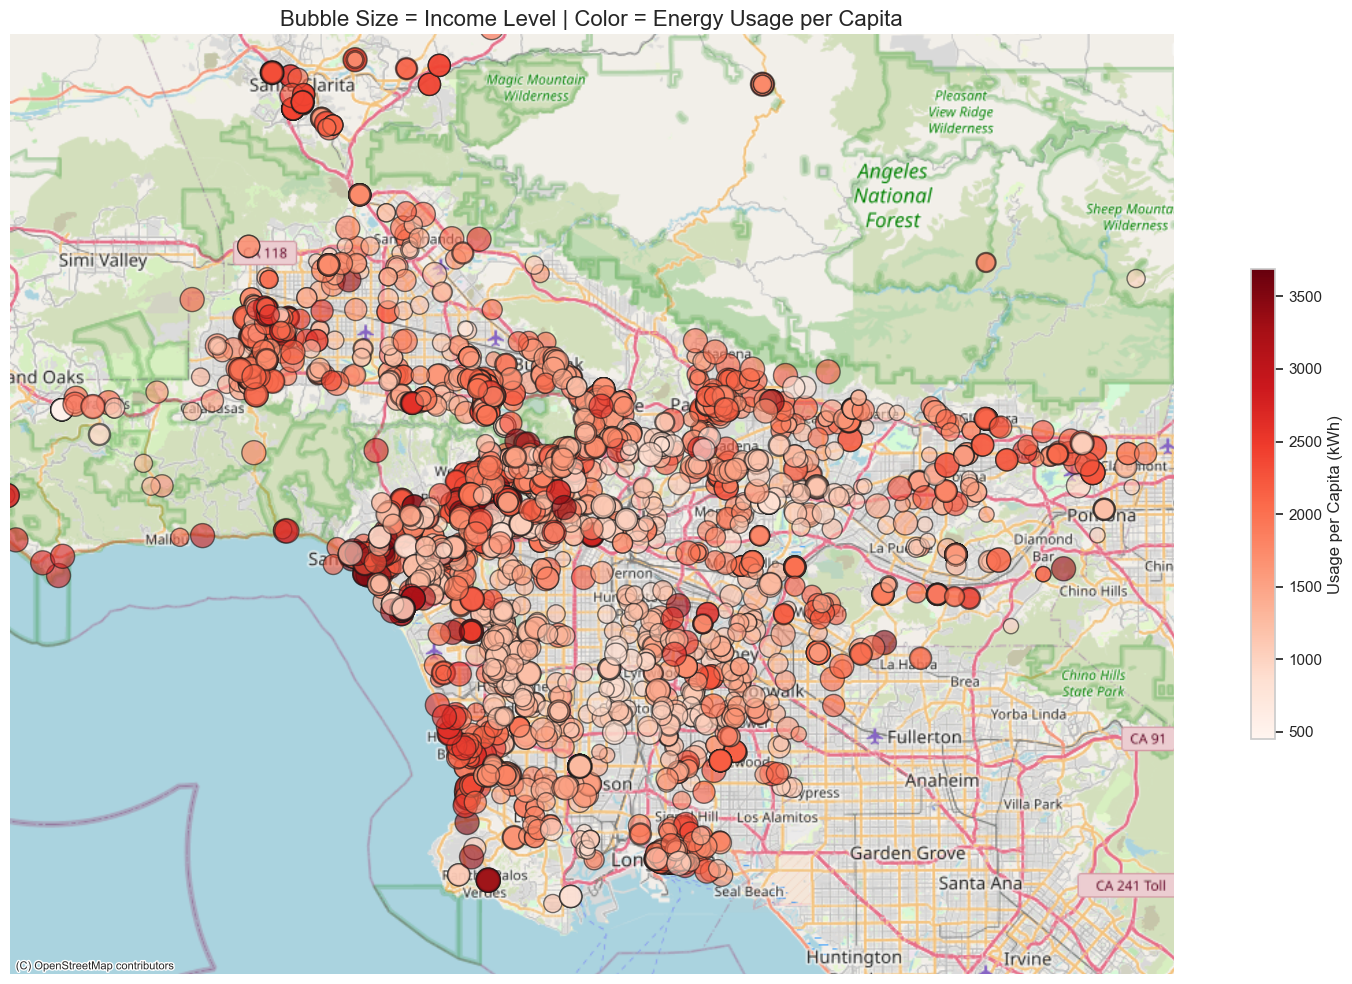

In [49]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Load your data
df = pd.read_csv("houses_final.csv")
df = df.dropna(subset=['latitude', 'longitude', 'usage_percap_predicted', 'income_range'])

# Optional filter
df = df[df['usage_percap_predicted'] < 50000]

# Map income_range to estimated income (midpoints)
income_map = {
    '< $41,685': 30000,
    '$41,685-$56,290': 49000,
    '$56,290-$74,167': 65000,
    '$74,167-$99,028': 86500,
    '> $99,028': 110000
}
df['income_estimate'] = df['income_range'].map(income_map)

# Drop rows with no income estimate
df = df.dropna(subset=['income_estimate'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# Project to Web Mercator
gdf = gdf.to_crs(epsg=3857)

# Bubble size reflects income
max_income = gdf['income_estimate'].max()
sizes = (gdf['income_estimate'] / max_income) ** 0.7  # Nonlinear scaling
sizes = sizes * 300      # Adjust multiplier as needed.

# Plot
fig, ax = plt.subplots(figsize=(16, 10))
gdf.plot(
    ax=ax,
    markersize=sizes,
    column='usage_percap_predicted',  # color shows energy usage
    cmap='Reds',
    alpha=0.6,
    edgecolor='k',
    legend=True,
    legend_kwds={'label': "Usage per Capita (kWh)", 'shrink': 0.5}
)

# Zoom into LA County
ax.set_xlim([-1.323e7, -1.310e7])
ax.set_ylim([3985000, 4090000])

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Final touches
ax.set_axis_off()
plt.title("Bubble Size = Income Level | Color = Energy Usage per Capita", fontsize=16)
plt.tight_layout()
plt.show()


## Income Range and Usage Per Capita - Bar Chart

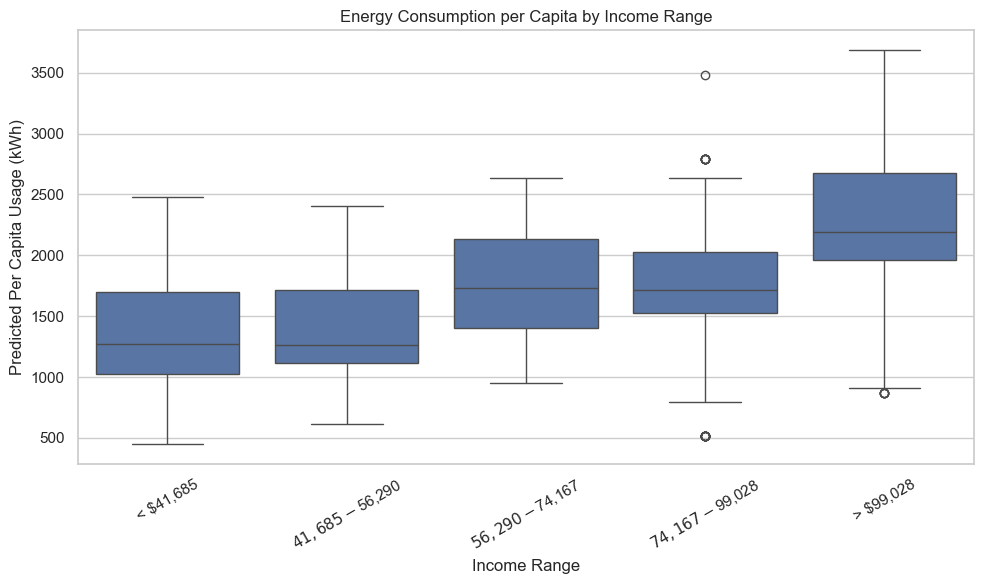

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("houses_final.csv")

# Drop rows with missing usage or income data
df = df.dropna(subset=['usage_med_predicted', 'usage_percap_predicted', 'income_range'])

# Set plot style
sns.set(style="whitegrid")

# Income level vs. Energy Consumption
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='income_range', y='usage_percap_predicted', order=[
    '< $41,685', '$41,685-$56,290', '$56,290-$74,167', '$74,167-$99,028', '> $99,028'
])
plt.title("Energy Consumption per Capita by Income Range")
plt.xlabel("Income Range")
plt.ylabel("Predicted Per Capita Usage (kWh)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Price and Usage Per Capita - Regression

In [324]:
import pandas as pd
import statsmodels.api as sm

# Load and clean data
df = pd.read_csv("houses_final.csv")
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['usage_percap_predicted'] = pd.to_numeric(df['usage_percap_predicted'], errors='coerce')

# Filter
df = df.dropna(subset=['price', 'usage_percap_predicted'])
df = df[df['usage_percap_predicted'] >= 0]
df = df[df['price'] <= 10000]
df = df[df['usage_percap_predicted'] <= 40000]

# Set up X and y
X = df['price']
y = df['usage_percap_predicted']
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())


                              OLS Regression Results                              
Dep. Variable:     usage_percap_predicted   R-squared:                       0.184
Model:                                OLS   Adj. R-squared:                  0.184
Method:                     Least Squares   F-statistic:                     786.9
Date:                    Mon, 05 May 2025   Prob (F-statistic):          2.77e-156
Time:                            20:56:43   Log-Likelihood:                -26705.
No. Observations:                    3483   AIC:                         5.341e+04
Df Residuals:                        3481   BIC:                         5.343e+04
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

## Solar Potential and Predicted Median Usage

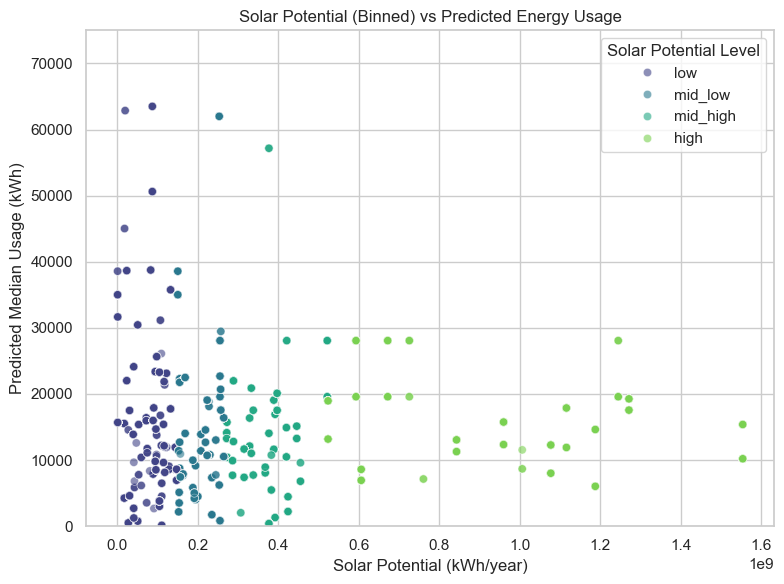

In [320]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("houses_final.csv")

# Drop missing values
df_solar = df.dropna(subset=['solar_pot', 'usage_med_predicted'])
df_solar = df_solar[df_solar['usage_med_predicted'] > 0]

# Bin solar potential into quartile-based categories
df_solar['solar_pot_category'] = pd.qcut(
    df_solar['solar_pot'],
    q=4,
    labels=['low', 'mid_low', 'mid_high', 'high']
)

# Plot usage vs. solar potential category
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_solar,
    x='solar_pot',
    #y='usage_med_predicted',
    y='usage_med_predicted',
    hue='solar_pot_category',
    palette='viridis',
    alpha=0.6
)

plt.ylim(0,75000)
plt.title("Solar Potential (Binned) vs Predicted Energy Usage")
plt.xlabel("Solar Potential (kWh/year)")
plt.ylabel("Predicted Median Usage (kWh)")
plt.legend(title="Solar Potential Level")
plt.tight_layout()
plt.show()


## RENT PRICE & ENERGY USAGE PER CAPITA - UNSURE

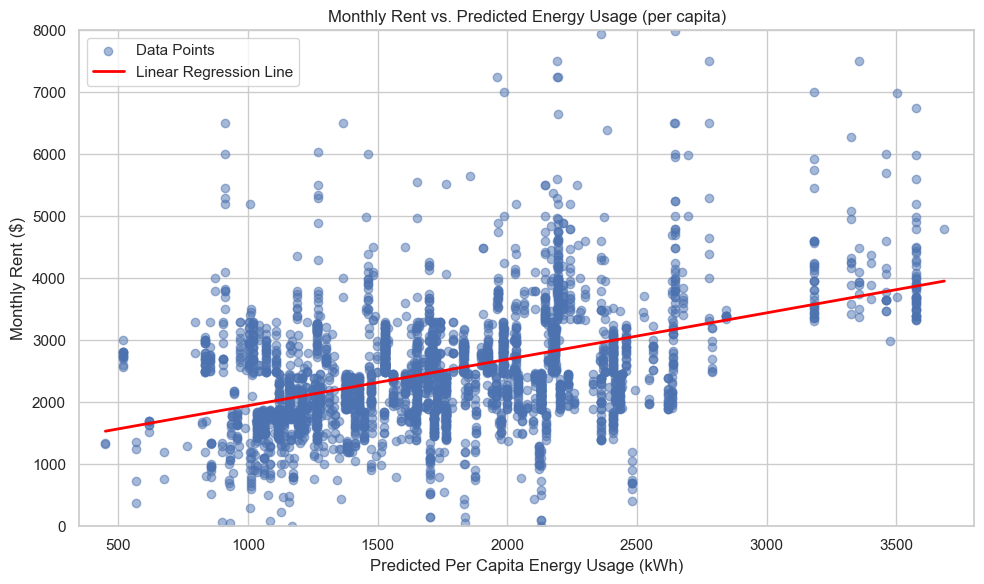

In [346]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Load data
houses = pd.read_csv('houses_final.csv')

# Ensure numeric types
houses['price'] = pd.to_numeric(houses['price'], errors='coerce')
houses['usage_percap_predicted'] = pd.to_numeric(houses['usage_percap_predicted'], errors='coerce')

# Drop rows with missing or negative usage
scatter_data = houses.dropna(subset=['price', 'usage_percap_predicted'])
scatter_data = scatter_data[scatter_data['usage_percap_predicted'] >= 0]

# Optional: Filter out extreme rent values (outliers)
scatter_data = scatter_data[scatter_data['price'] <= 10000]

# Optional: Filter usage for better visualization
scatter_data = scatter_data[scatter_data['usage_percap_predicted'] <= 40000]

# Prepare regression inputs
X = scatter_data['usage_percap_predicted'].values.reshape(-1, 1)
y = scatter_data['price'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict regression line
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(scatter_data['usage_percap_predicted'], scatter_data['price'], alpha=0.5, label='Data Points')
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.xlabel('Predicted Per Capita Energy Usage (kWh)')
plt.ylabel('Monthly Rent ($)')
plt.title('Monthly Rent vs. Predicted Energy Usage (per capita)')
plt.xlim(350, 3800)
plt.ylim(0, 8000)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---
## Linear Regression

In [340]:
import pandas as pd
import statsmodels.api as sm

# Load data
df = pd.read_csv("houses_final.csv")

# Keep only numeric predictors and drop missing
df = df[['price', 'square_feet', 'usage_med_predicted', 'usage_percap_predicted', 'bedrooms', 'bathrooms', 'solar_pot']].copy()
df = df.dropna()

# Define X and y
#X2 = df[['price', 'square_feet', 'usage_percap_predicted']]
#X2 = df[[ 'square_feet', 'usage_percap_predicted']] # without price

X2 = df[['bedrooms', 'bathrooms', 'price', 'square_feet', 'usage_percap_predicted']]

y2 = df['usage_med_predicted']

# Add constant
X2 = sm.add_constant(X2)

# Fit model
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())


                             OLS Regression Results                            
Dep. Variable:     usage_med_predicted   R-squared:                       0.486
Model:                             OLS   Adj. R-squared:                  0.486
Method:                  Least Squares   F-statistic:                     659.6
Date:                 Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                         21:39:31   Log-Likelihood:                -37184.
No. Observations:                 3487   AIC:                         7.438e+04
Df Residuals:                     3481   BIC:                         7.442e+04
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             